<a href="https://colab.research.google.com/github/DevikaRelangi-glitch/Worlflow1/blob/main/K_Nearest_Neighbour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**K-Nearest Neighbor:**

K-Nearest Neighbors (KNN) is a simple, instance-based algorithm that classifies a data point by finding the k closest labeled points and assigning the label that appears most frequently among them.

It is a simple algorithm that stores all the available traning data and it uses the training data directly to determine the nearest neighbors for any new input

Here’s a Python implementation of the K-Nearest Neighbors (KNN) algorithm for detecting fraud in the Credit Card Fraud Detection dataset from Kaggle. This dataset classifies transactions as fraudulent (1) or non-fraudulent (0), with the goal of identifying potential fraud based on transaction features.

**Step 1: Import Required Libraries**

In [ ]:
# Import necessary libraries
import pandas as pd                   # For data manipulation
from sklearn.model_selection import train_test_split # For splitting data
from sklearn.preprocessing import StandardScaler     # For scaling features
from sklearn.neighbors import KNeighborsClassifier   # For KNN model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # For evaluation
import seaborn as sns                 # For plotting
import matplotlib.pyplot as plt       # For plotting
from google.colab import files        # For file handling
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


NumPy: Essential for performing numerical operations.

Matplotlib: Enables data visualization.

scikit-learn modules: Provides tools to create polynomial features and evaluate performance.

**Step 2: Load and Inspect the Data**

Load the dataset and inspect the structure. I downloaded the dataset from Kaggle and uploaded from my local desktop.

In [ ]:
# Load the dataset
data = pd.read_csv('creditcard.csv')

# Check the basic structure of the dataset
print("Dataset shape:", data.shape)
print("First 5 rows:\n", data.head())
print("Class distribution:\n", data['Class'].value_counts())


Dataset shape: (284807, 31)
First 5 rows:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.

data.shape shows the number of rows and columns in the dataset.

data.head() shows the first few rows, helping you understand the columns.

data['Class'].value_counts() displays the distribution of classes (0: Non-fraud, 1: Fraud), which will likely be imbalanced.

**Step 3: Handle Class Imbalance**

The dataset is highly imbalanced, so you can either undersample the majority class or oversample the minority class. Here, we’ll use undersampling for simplicity.

In [ ]:
# Separate the fraudulent and non-fraudulent transactions
fraud = data[data['Class'] == 1]
non_fraud = data[data['Class'] == 0]

# Undersample the non-fraudulent transactions
non_fraud_sample = non_fraud.sample(len(fraud), random_state=42)

# Combine the two classes into a new balanced dataset
data_balanced = pd.concat([fraud, non_fraud_sample])

# Check the new class distribution
print("Balanced class distribution:\n", data_balanced['Class'].value_counts())


Balanced class distribution:
 Class
1    492
0    492
Name: count, dtype: int64


**Step 4: Split Data into Features and Target, and Train-Test Split**

Now, split the balanced dataset into features (X) and the target label (y). We’ll use an 80-20 split.

In [ ]:
# Define features (X) and target (y)
X = data_balanced.drop(columns=['Class'])
y = data_balanced['Class']

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (787, 30)
Testing set shape: (197, 30)


**Step 5: Scale the Features**

Feature scaling is crucial for KNN since it uses distance calculations. We’ll use StandardScaler to standardize the features.

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**Step 6: Train the KNN Model**

We’ll initialize and train the KNN model with k=5. You can experiment with different values of k.

In [ ]:
# Initialize the KNN classifier with 5 neighbors
k = 5
knn = KNeighborsClassifier(n_neighbors=k)

# Train the model on the training data
knn.fit(X_train, y_train)
print(f"KNN model trained with k = {k}")


KNN model trained with k = 5


**Step 7: Make Predictions and Evaluate the Model**

We’ll predict the labels of the test set and evaluate using accuracy, classification report, and confusion matrix.



Accuracy: 0.9238578680203046

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.99      0.93        98
           1       0.99      0.86      0.92        99

    accuracy                           0.92       197
   macro avg       0.93      0.92      0.92       197
weighted avg       0.93      0.92      0.92       197



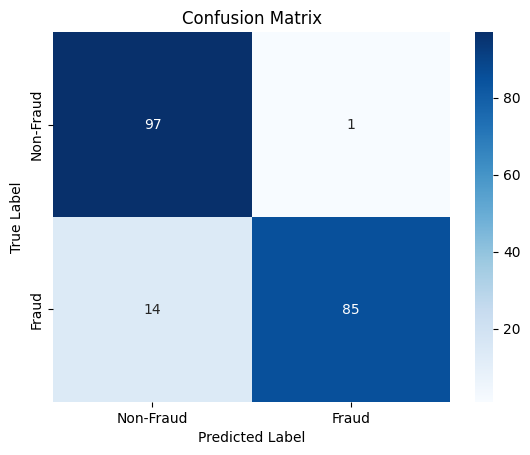

In [ ]:
# Predict the labels on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Print a detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot the confusion matrix for a visual evaluation
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


**Evaluation Metrics**

Accuracy: The percentage of correctly classified samples.

Classification Report: Provides precision, recall, and F1-score for each class.

Precision: The percentage of positive predictions that are actually correct.

Recall: The percentage of actual positives that were correctly identified.

F1-score: The harmonic mean of precision and recall, useful in imbalanced data situations.

Support: The number of actual occurrences of the class in the specified dataset.

Confusion Matrix: Shows the counts of true positives, true negatives, false positives, and false negatives.